# 10 绩效评估、基准对比与策略报告

## 10.1 本章要解决什么问题

第 09 章已经把“目标权重 -> 滞后持仓 -> 扣成本后的日收益和净值”跑通。回测结束后，真正要交给自己复盘的不是一句“策略表现不错”，而是一组可检查的证据：收益、波动、回撤、胜率、相对基准表现，以及可以长期留档的图表和报告。

本章会先手写核心绩效指标，确保公式口径透明；再使用 `lib.evaluation` 和 `lib.reporting` 保存结果到 `outputs/results/`。这些输出只是历史样本上的评估材料，不构成 alpha、收益或实盘可行性的承诺。

## 10.2 学完你应该能做到

1. 从回测日收益计算年化收益、年化波动、夏普比率、最大回撤、日胜率。
2. 选择一个基准，计算策略相对基准的超额收益和跟踪误差。
3. 读懂净值图、回撤图、基准对比图、指标表和 QuantStats HTML 报告各自回答的问题。
4. 把评估结果保存为可复盘的文件，并把这些文件交给第 11 章的工程化流水线继续使用。

## 10.3 输入与输出

输入：第 09 章同一套 ETF 样例数据、因子打分、TopN 权重和回测收益序列。这里直接调用实践流水线得到相同对象，避免复制太多上游代码。

输出目录：`outputs/results/`

主要产物：`performance_metrics.csv`、`nav_curve.png`、`drawdown_curve.png`、`benchmark_comparison.png`、`quantstats_report.html`、`strategy_returns.csv`，以及第 11 章会继续使用的目标权重和订单建议文件。


In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "lib").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Cannot find pyquant-roadmap project root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from lib.paths import RESULTS_DIR

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
pd.Series({"project_root": ".", "results_dir": RESULTS_DIR.relative_to(PROJECT_ROOT).as_posix()}, name="value")


project_root                  .
results_dir     outputs/results
Name: value, dtype: object

## 10.4 取得上游回测结果

本章的重点不是重新发明因子和回测引擎，而是评价已经得到的回测结果。因此这里使用 `run_etf_strategy_pipeline` 取得实践流水线的输出：

- `report`：逐日收益、成本、换手和净值。
- `prices`：样例 ETF 的价格数据，用来构造基准收益。
- `target_weights`：历史目标权重，用于做一个简单的收益贡献拆解。
- `assets`：流水线已经保存到磁盘的结果文件。

第 11 章会把这个调用进一步工程化：配置参数、实验记录、最新权重和交易信号都会围绕同一批对象展开。


In [2]:
from lib.pipeline import run_etf_strategy_pipeline

result = run_etf_strategy_pipeline(output_dir=RESULTS_DIR)
report = result["report"].copy()
prices = result["prices"].copy()

report.index = pd.to_datetime(report.index)
prices["date"] = pd.to_datetime(prices["date"])

summary = pd.Series(
    {
        "start_date": report.index.min().date(),
        "end_date": report.index.max().date(),
        "trading_days": len(report),
        "last_nav": report["nav"].iloc[-1],
        "avg_turnover": report["turnover"].mean(),
    }
)

display(summary)
display(report.tail())


start_date      2021-01-04
end_date        2023-12-29
trading_days           725
last_nav            0.7628
avg_turnover        0.0133
dtype: object

,gross_return,cost,strategy_return,nav,turnover
date,,,,,
2023-12-25,-0.0001,0.0000,-0.0001,0.7434,0.0000
2023-12-26,-0.0096,0.0000,-0.0096,0.7363,0.0000
2023-12-27,0.0041,0.0000,0.0041,0.7393,0.0000
2023-12-28,0.0227,0.0000,0.0227,0.7561,0.0000
2023-12-29,0.0089,0.0000,0.0089,0.7628,0.0000


## 10.5 准备策略收益和基准收益

绩效评价必须先明确“和谁比”。这里为了让 notebook 可以离线运行，直接使用样例 ETF 池中的第一只 ETF 作为买入并持有基准。真实研究里，基准应当和策略的投资范围、风险暴露、交易约束相匹配，例如宽基指数、行业指数、货币基金或自定义组合。

基准选择会显著影响“超额收益”的解释，所以后面会留一个小练习让你换一个基准再看结果。


In [3]:
close = prices.pivot(index="date", columns="code", values="close").sort_index().astype(float)
asset_returns = close.pct_change().fillna(0.0)

strategy_returns = report["strategy_return"].rename("strategy")
strategy_nav = report["nav"].rename("Strategy")

benchmark_code = close.columns[0]
benchmark_returns = asset_returns[benchmark_code].rename(f"{benchmark_code}_benchmark")
benchmark_nav = (1.0 + benchmark_returns).cumprod().rename(f"Benchmark {benchmark_code}")

return_sample = pd.concat([strategy_returns, benchmark_returns], axis=1).dropna()
nav_sample = pd.concat([strategy_nav, benchmark_nav], axis=1).dropna()

display(pd.Series({"benchmark_code": benchmark_code, "aligned_days": len(return_sample)}))
display(return_sample.tail())


benchmark_code    159915
aligned_days         725
dtype: object

,strategy,159915_benchmark
date,,
2023-12-25,-0.0001,0.0017
2023-12-26,-0.0096,-0.0123
2023-12-27,0.0041,0.0011
2023-12-28,0.0227,0.0397
2023-12-29,0.0089,0.0049


## 10.6 手写核心绩效指标

下面的函数只依赖 `pandas` 和 `numpy`。这样做的目的不是替代成熟库，而是把口径讲清楚：

- 年化收益：把累计收益按交易日数量折算到一年。
- 年化波动：日收益标准差乘以 `sqrt(252)`。
- 夏普比率：这里使用零无风险利率近似，即“平均日收益 / 日波动 * sqrt(252)”。
- 最大回撤：净值相对历史最高点的最大跌幅。
- 日胜率：日收益大于 0 的比例。它不是单笔交易胜率。
- 基准超额：策略年化收益减去基准年化收益；它描述相对表现，不证明未来有 alpha。


In [4]:
PERIODS_PER_YEAR = 252


def clean_returns(returns: pd.Series) -> pd.Series:
    return returns.dropna().astype(float)


def annual_return(returns: pd.Series, periods_per_year: int = PERIODS_PER_YEAR) -> float:
    returns = clean_returns(returns)
    if returns.empty:
        return np.nan
    total_growth = float((1.0 + returns).prod())
    if total_growth < 0:
        return np.nan
    return total_growth ** (periods_per_year / len(returns)) - 1.0


def annual_volatility(returns: pd.Series, periods_per_year: int = PERIODS_PER_YEAR) -> float:
    returns = clean_returns(returns)
    return returns.std(ddof=0) * np.sqrt(periods_per_year)


def sharpe_ratio(returns: pd.Series, periods_per_year: int = PERIODS_PER_YEAR) -> float:
    returns = clean_returns(returns)
    std = returns.std(ddof=0)
    if std == 0 or np.isclose(std, 0):
        return np.nan
    return returns.mean() / std * np.sqrt(periods_per_year)


def nav_from_returns(returns: pd.Series) -> pd.Series:
    returns = clean_returns(returns)
    return (1.0 + returns).cumprod()


def max_drawdown_from_nav(nav: pd.Series) -> float:
    nav = nav.dropna().astype(float)
    dd = nav / nav.cummax() - 1.0
    return float(dd.min())


def daily_win_rate(returns: pd.Series) -> float:
    returns = clean_returns(returns)
    if returns.empty:
        return np.nan
    return float((returns > 0).mean())


def summarize_manual_metrics(
    returns: pd.Series,
    benchmark: pd.Series | None = None,
    periods_per_year: int = PERIODS_PER_YEAR,
) -> dict[str, float]:
    returns = clean_returns(returns)
    nav = nav_from_returns(returns)
    stats = {
        "total_return": float(nav.iloc[-1] - 1.0),
        "ann_return": annual_return(returns, periods_per_year),
        "ann_vol": annual_volatility(returns, periods_per_year),
        "sharpe": sharpe_ratio(returns, periods_per_year),
        "max_drawdown": max_drawdown_from_nav(nav),
        "win_rate": daily_win_rate(returns),
    }
    if benchmark is not None:
        aligned = pd.concat([returns, clean_returns(benchmark)], axis=1).dropna()
        aligned.columns = ["strategy", "benchmark"]
        benchmark_ann = annual_return(aligned["benchmark"], periods_per_year)
        active = aligned["strategy"] - aligned["benchmark"]
        stats.update(
            {
                "benchmark_ann_return": benchmark_ann,
                "excess_ann_return": annual_return(aligned["strategy"], periods_per_year) - benchmark_ann,
                "tracking_error": annual_volatility(active, periods_per_year),
            }
        )
    return stats


def format_metric(metric: str, value: float) -> str:
    if pd.isna(value):
        return "NA"
    percent_metrics = {
        "total_return",
        "ann_return",
        "ann_vol",
        "max_drawdown",
        "win_rate",
        "benchmark_ann_return",
        "excess_ann_return",
        "tracking_error",
    }
    if metric in percent_metrics:
        return f"{value:.2%}"
    return f"{value:.2f}"


In [5]:
manual_stats = summarize_manual_metrics(strategy_returns, benchmark_returns)
manual_table = pd.Series(manual_stats, name="value").to_frame()
manual_table["display"] = [format_metric(metric, value) for metric, value in manual_table["value"].items()]
manual_table


,value,display
total_return,-0.2372,-23.72%
ann_return,-0.0898,-8.98%
ann_vol,0.1731,17.31%
sharpe,-0.4567,-0.46
max_drawdown,-0.3661,-36.61%
win_rate,0.4359,43.59%
benchmark_ann_return,-0.1536,-15.36%
excess_ann_return,0.0638,6.38%
tracking_error,0.1550,15.50%


### 10.6.1 如何读这张指标表

单个指标不能单独下结论：

- 年化收益高但最大回撤也大，可能只是承担了更多风险。
- 夏普比率对收益分布形态很敏感，不能替代压力测试。
- 胜率高不代表赚钱，单日小赢大亏也会产生糟糕净值。
- 超额收益依赖基准选择；换一个基准，结论可能变化。

所以报告要同时保存收益、风险、相对基准和图表证据。


## 10.7 用 `lib.evaluation` 复现指标和图表

手写函数讲原理，`lib.evaluation` 负责复用同一套口径。`perf_stats` 会返回可保存的指标字典，图表函数则生成 matplotlib Figure，既能在 notebook 中查看，也能保存成图片。


In [6]:
from lib.evaluation.metrics import drawdown, perf_stats
from lib.evaluation.plots import plot_drawdown, plot_nav, plot_nav_comparison

lib_stats = perf_stats(strategy_returns, benchmark_returns)
lib_table = pd.Series(lib_stats, name="value").to_frame()
lib_table["display"] = [format_metric(metric, value) for metric, value in lib_table["value"].items()]
lib_table


,value,display
ann_return,-0.0898,-8.98%
ann_vol,0.1731,17.31%
sharpe,-0.4567,-0.46
max_drawdown,-0.3661,-36.61%
total_return,-0.2372,-23.72%
win_rate,0.4359,43.59%
benchmark_total_return,-0.3810,-0.38
benchmark_ann_return,-0.1536,-15.36%
excess_total_return,0.1438,0.14
excess_ann_return,0.0638,6.38%


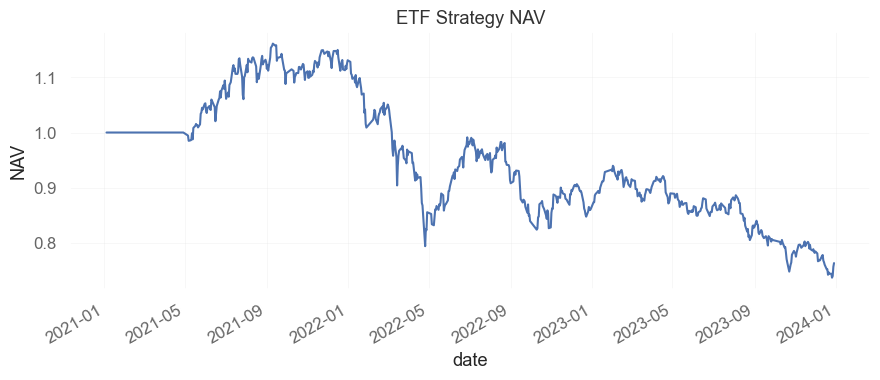

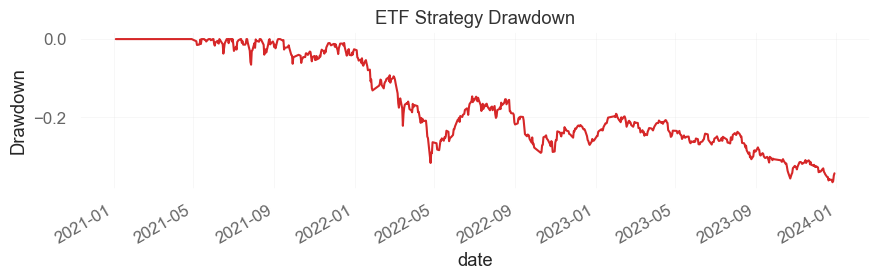

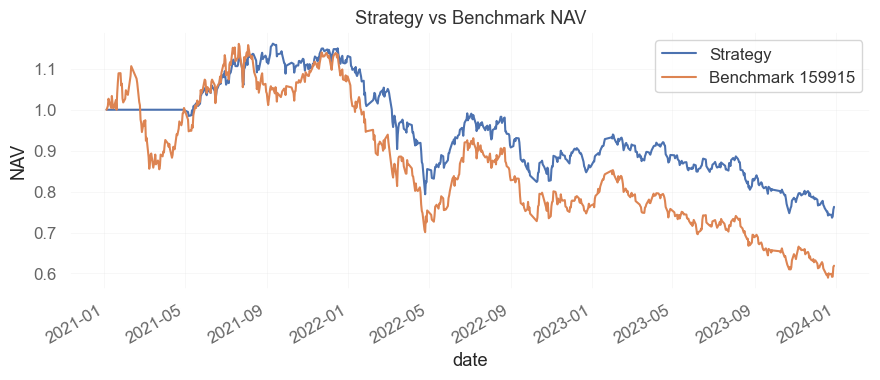

In [7]:
fig_nav, _ = plot_nav(strategy_nav, title="ETF Strategy NAV")
fig_dd, _ = plot_drawdown(strategy_nav, title="ETF Strategy Drawdown")
fig_bench, _ = plot_nav_comparison(strategy_nav, benchmark_nav, title="Strategy vs Benchmark NAV")

plt.show()


## 10.8 一个轻量级归因视角：哪些资产贡献了收益

严格的业绩归因需要把资产配置、选择效应、行业/风格暴露等拆开。本章先做一个可解释的轻量版本：用第 09 章同样的滞后持仓，计算每天“持仓权重 * 资产日收益”，再按资产汇总。

这张表只能回答“在这个历史样本中，组合日收益主要来自哪些 ETF 的持仓贡献”，不能说明这些资产未来仍会贡献收益。


In [8]:
positions = result["target_weights"].shift(1).fillna(0.0)
aligned_asset_returns = asset_returns.reindex(index=positions.index, columns=positions.columns).fillna(0.0)
return_contribution = positions * aligned_asset_returns

contribution_summary = pd.DataFrame(
    {
        "total_contribution": return_contribution.sum(),
        "avg_weight": positions.mean(),
        "last_weight": result["target_weights"].iloc[-1],
    }
).sort_values("total_contribution", ascending=False)

contribution_path = RESULTS_DIR / "return_contribution_summary.csv"
contribution_summary.to_csv(contribution_path, encoding="utf-8-sig")
contribution_summary


,total_contribution,avg_weight,last_weight
code,,,
510500,-0.0256,0.2878,0.3333
512100,-0.0393,0.2703,0.3333
159915,-0.0678,0.0970,0.0000
510300,-0.0871,0.2372,0.3333


## 10.9 用 `lib.reporting` 保存策略报告

`lib.reporting.save_strategy_results` 会把指标表、净值图、回撤图、基准对比图、最新目标权重和订单建议写到 `outputs/results/`。`generate_quantstats_report` 会额外生成一个 HTML 报告，适合快速浏览更完整的回测统计。

QuantStats 的价值是覆盖面广、浏览方便；它抽象掉了很多指标细节。所以学习时应先理解前面的手写指标，再把 HTML 报告当作复盘辅助。


In [9]:
from lib.reporting import generate_quantstats_report, save_strategy_results

saved_paths = save_strategy_results(
    strategy_returns,
    strategy_nav,
    result["latest_target_weights"],
    result["orders"],
    RESULTS_DIR,
    benchmark_returns=benchmark_returns,
)

saved_paths["quantstats_report"] = generate_quantstats_report(
    strategy_returns,
    RESULTS_DIR / "quantstats_report.html",
    benchmark_returns=benchmark_returns,
    title="xyQuant ETF Strategy Performance Review",
)
saved_paths["strategy_returns"] = result["assets"].get("strategy_returns")
saved_paths["factor_scores"] = result["assets"].get("factor_scores")
saved_paths["return_contribution"] = contribution_path

artifact_table = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": str(Path(path).relative_to(PROJECT_ROOT)),
            "exists": Path(path).exists(),
            "size_kb": round(Path(path).stat().st_size / 1024, 1) if Path(path).exists() else 0.0,
        }
        for name, path in saved_paths.items()
        if path is not None
    ]
).sort_values("artifact")

artifact_table


,artifact,path,exists,size_kb
6,benchmark_comparison,outputs\results\benchmark_comparison.png,True,118.7000
1,drawdown_curve,outputs\results\drawdown_curve.png,True,57.5000
9,factor_scores,outputs\results\factor_scores.csv,True,417.5000
2,metrics_csv,outputs\results\performance_metrics.csv,True,0.5000
3,metrics_md,outputs\results\performance_metrics.md,True,0.6000
0,nav_curve,outputs\results\nav_curve.png,True,69.4000
7,quantstats_report,outputs\results\quantstats_report.html,True,727.4000
10,return_contribution,outputs\results\return_contribution_summary.csv,True,0.3000
8,strategy_returns,outputs\results\strategy_returns.csv,True,54.8000
4,target_weights,outputs\results\target_weights.csv,True,0.2000


### 10.9.1 每个产物回答什么问题

- `performance_metrics.csv` / `.md`：核心收益、风险、胜率和相对基准指标，适合记录到实验表。
- `nav_curve.png`：策略净值路径，观察长期趋势和是否依赖少数阶段。
- `drawdown_curve.png`：历史回撤路径，观察亏损深度和恢复时间。
- `benchmark_comparison.png`：策略和基准的净值对比，检查相对表现是否稳定。
- `quantstats_report.html`：更完整的 HTML 报告，适合复盘，但不要把自动指标当成未来收益证明。
- `return_contribution_summary.csv`：简单的资产收益贡献表，用来辅助解释回测结果。
- `target_weights.csv` / `trade_orders.csv`：第 11 章会继续工程化处理的目标权重和订单建议。


## 10.10 质量检查与常见坑

评价报告最常见的错误有三个：

1. 策略收益和基准收益没有按日期对齐，导致超额收益失真。
2. 把日频数据当成月频或周频年化，导致指标数量级错误。
3. 只看最终收益，不看回撤、波动、成本和基准。

下面用几个轻量检查确认本章输出可以交给下一章。


In [10]:
checks = {
    "strategy_returns_aligned": strategy_returns.index.equals(report.index),
    "benchmark_has_same_calendar": return_sample.index.equals(strategy_returns.loc[return_sample.index].index),
    "nav_positive": bool((strategy_nav > 0).all()),
    "metrics_saved": bool((RESULTS_DIR / "performance_metrics.csv").exists()),
    "html_report_saved": bool((RESULTS_DIR / "quantstats_report.html").exists()),
    "benchmark_chart_saved": bool((RESULTS_DIR / "benchmark_comparison.png").exists()),
}

quality_checks = pd.Series(checks, name="passed")
display(quality_checks)
assert quality_checks.all()


strategy_returns_aligned       True
benchmark_has_same_calendar    True
nav_positive                   True
metrics_saved                  True
html_report_saved              True
benchmark_chart_saved          True
Name: passed, dtype: bool

## 10.11 练习：换一个基准再看超额收益

如果 ETF 池里有多只资产，下面把基准换成第二只 ETF。观察 `benchmark_ann_return` 和 `excess_ann_return` 如何变化。你可以继续把 `exercise_benchmark_code` 改成其他代码，体会“基准选择”对结论的影响。


In [11]:
exercise_benchmark_code = close.columns[1] if len(close.columns) > 1 else benchmark_code
exercise_benchmark_returns = asset_returns[exercise_benchmark_code].rename(f"{exercise_benchmark_code}_benchmark")
exercise_stats = summarize_manual_metrics(strategy_returns, exercise_benchmark_returns)
exercise_table = pd.Series(exercise_stats, name="value").to_frame()
exercise_table["display"] = [format_metric(metric, value) for metric, value in exercise_table["value"].items()]
exercise_table.loc[["ann_return", "benchmark_ann_return", "excess_ann_return", "tracking_error"]]


,value,display
ann_return,-0.0898,-8.98%
benchmark_ann_return,-0.1324,-13.24%
excess_ann_return,0.0425,4.25%
tracking_error,0.1224,12.24%


## 10.12 交给第 11 章

到这里，我们已经把回测结果转成了可复盘的指标、图表、HTML 报告和简单贡献拆解。第 11 章会把这些动作放进工程化流程：从配置读取参数，稳定生成结果文件，记录实验元信息，并把最新目标权重转成交易信号。

继续向后运行时，请记住本章的边界：历史绩效报告用于审查策略假设和风险，不用于承诺未来收益。
